##Iris Flower Classification

**Objective:** Build a machine learning model that classifies an Iris flower into one of three species — *setosa*, *versicolor*, or *virginica* — using four physical measurements (sepal length, sepal width, petal length, petal width).

**Workflow:**
1. Load and explore the dataset
2. Exploratory Data Analysis (EDA) with visualizations
3. Data preprocessing
4. Train multiple classification models
5. Evaluate model performance (accuracy, confusion matrix, classification report)
6. Make predictions on new samples

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

## 1. Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load the Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [4]:
df = pd.read_csv('Iris.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# Drop the Id column as it is not a predictive feature
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Initial Exploration

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
# Check class balance and missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\nClass distribution:')
print(df['Species'].value_counts())

Missing values per column:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


**Observation:** No missing values, and the dataset is perfectly balanced — 50 samples for each of the three species.

## 4. Exploratory Data Analysis (EDA)

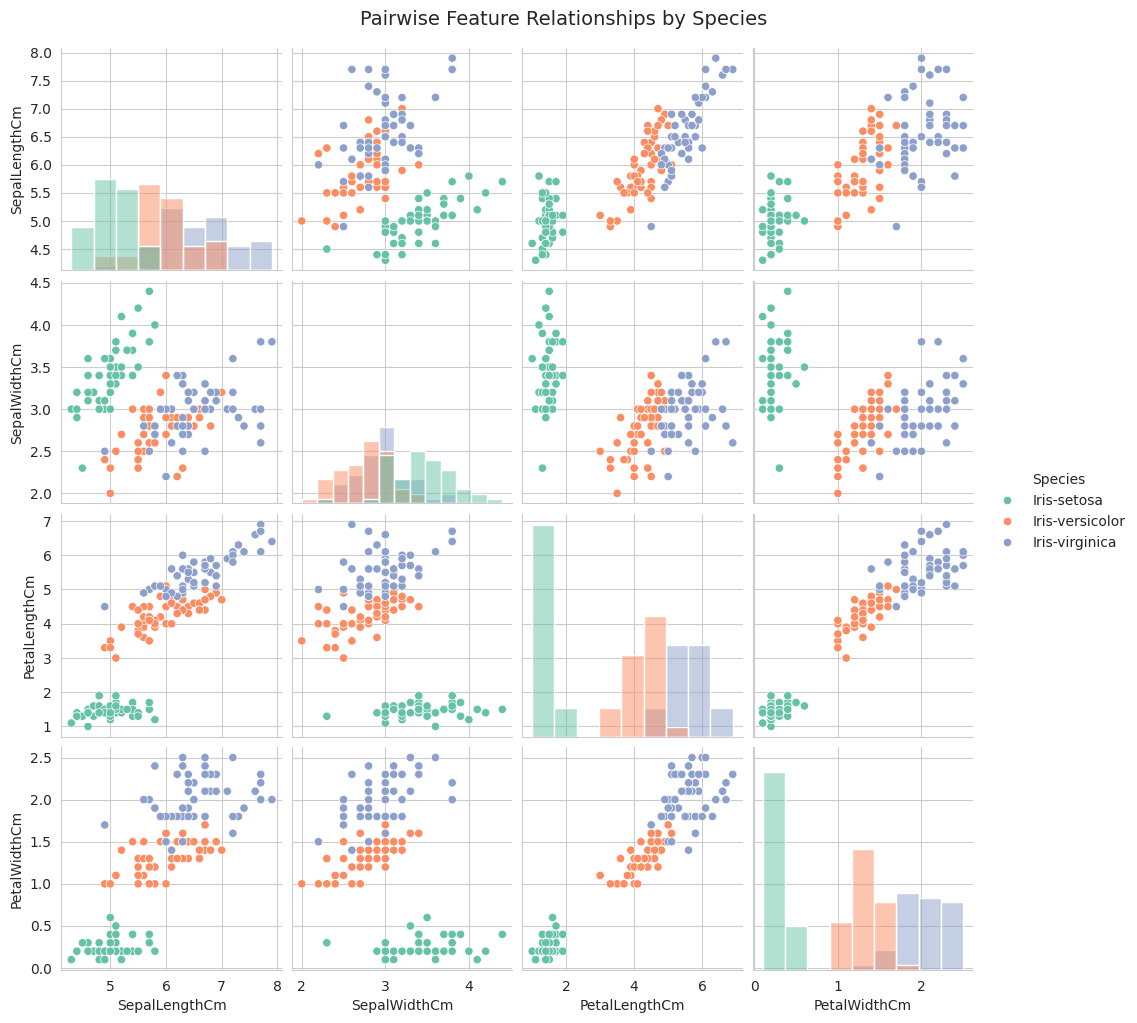

In [9]:
# Pairplot — shows relationships between every pair of features, colored by species
sns.pairplot(df, hue='Species', diag_kind='hist', palette='Set2')
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02, fontsize=14)
plt.show()

**Insight:** *Iris-setosa* is clearly linearly separable from the other two species, especially using petal measurements. *versicolor* and *virginica* overlap slightly but are still mostly distinguishable.

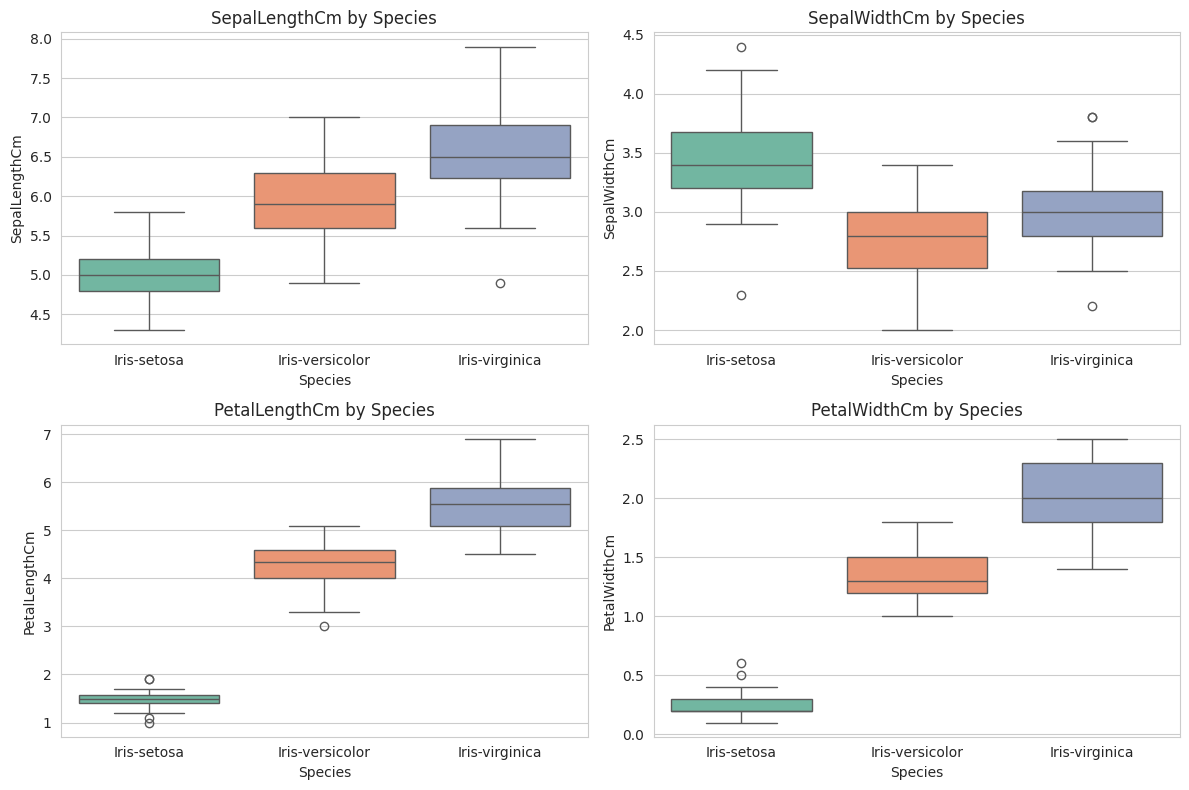

In [10]:
# Boxplots for each feature by species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
for ax, feature in zip(axes.flat, features):
    sns.boxplot(x='Species', y=feature, data=df, ax=ax, palette='Set2')
    ax.set_title(f'{feature} by Species')
plt.tight_layout()
plt.show()

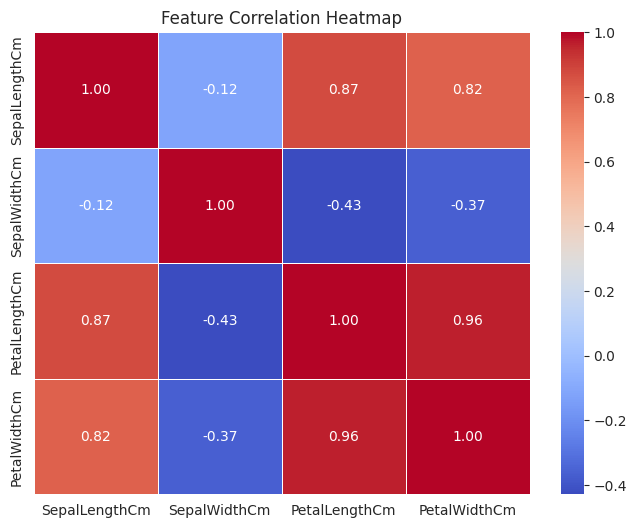

In [11]:
# Correlation heatmap of the numeric features
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop('Species', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

**Insight:** Petal length and petal width are very strongly correlated (~0.96). Both are also strongly correlated with sepal length. These petal measurements are likely the most discriminative features.

## 5. Data Preprocessing

In [12]:
# Separate features (X) and target (y)
X = df.drop('Species', axis=1)
y = df['Species']

# Encode the target labels into numeric form
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print('Classes:', list(le.classes_))
print('Encoded sample:', y_encoded[:5])

Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Encoded sample: [0 0 0 0 0]


In [13]:
# Train-test split (80/20, stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print('Training set:', X_train.shape, '|  Test set:', X_test.shape)

Training set: (120, 4) |  Test set: (30, 4)


In [14]:
# Feature scaling — important for distance-based algorithms (KNN, SVM, Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Train Multiple Classification Models

We compare five popular classifiers and pick the best performer.

In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    results[name] = {
        'test_accuracy': acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'model': model,
        'predictions': y_pred
    }
    print(f'{name:25s} | Test Acc: {acc:.4f} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Logistic Regression       | Test Acc: 0.9333 | CV: 0.9583 ± 0.0264
K-Nearest Neighbors       | Test Acc: 0.9333 | CV: 0.9667 ± 0.0312
Decision Tree             | Test Acc: 0.9333 | CV: 0.9417 ± 0.0204
Random Forest             | Test Acc: 0.9000 | CV: 0.9500 ± 0.0167
Support Vector Machine    | Test Acc: 0.9667 | CV: 0.9667 ± 0.0312


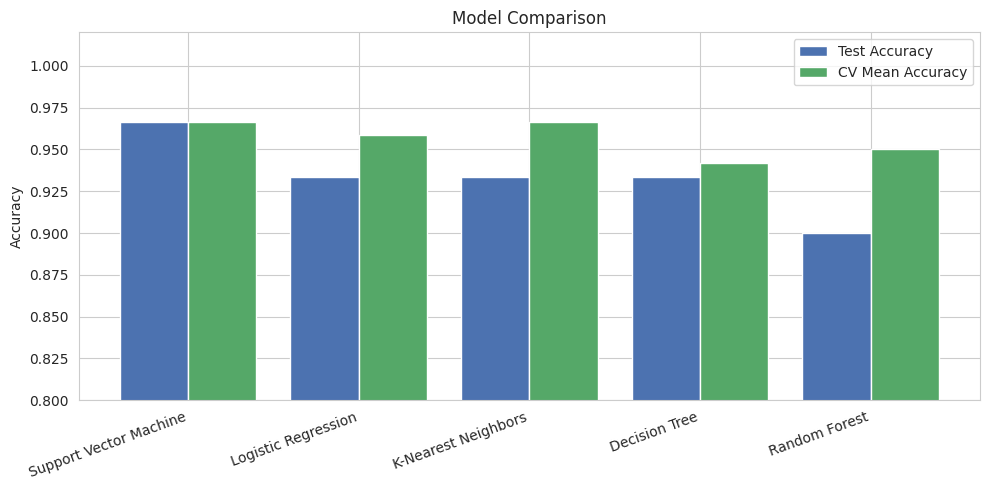

,Model,Test Accuracy,CV Mean Accuracy
0,Support Vector Machine,0.966667,0.966667
1,Logistic Regression,0.933333,0.958333
2,K-Nearest Neighbors,0.933333,0.966667
3,Decision Tree,0.933333,0.941667
4,Random Forest,0.900000,0.950000


In [16]:
# Visualize the comparison
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [r['test_accuracy'] for r in results.values()],
    'CV Mean Accuracy': [r['cv_mean'] for r in results.values()]
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
ax.bar(x - 0.2, results_df['Test Accuracy'], 0.4, label='Test Accuracy', color='#4C72B0')
ax.bar(x + 0.2, results_df['CV Mean Accuracy'], 0.4, label='CV Mean Accuracy', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

results_df

## 7. Evaluate the Best Model

In [17]:
best_model_name = max(results, key=lambda k: results[k]['test_accuracy'])
best_model = results[best_model_name]['model']
best_pred  = results[best_model_name]['predictions']

print(f'🏆 Best Model: {best_model_name}')
print(f'   Test Accuracy: {results[best_model_name]["test_accuracy"]:.4f}')

🏆 Best Model: Support Vector Machine
   Test Accuracy: 0.9667


In [18]:
# Detailed classification report
print('Classification Report:\n')
print(classification_report(y_test, best_pred, target_names=le.classes_))

Classification Report:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



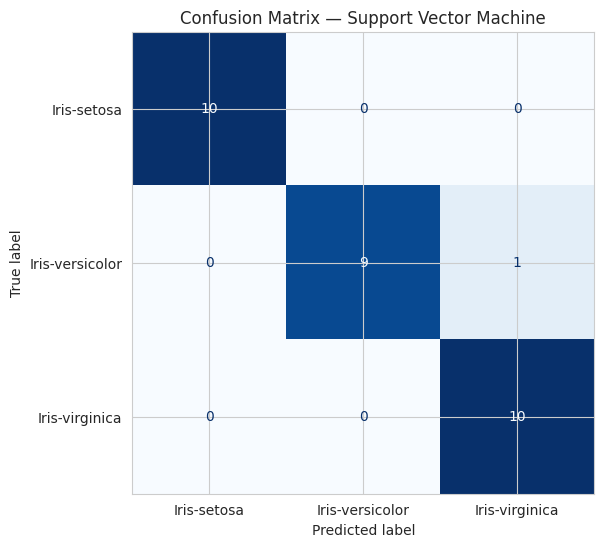

In [19]:
# Confusion matrix
cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(
    cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.show()

## 8. Feature Importance (using Random Forest)

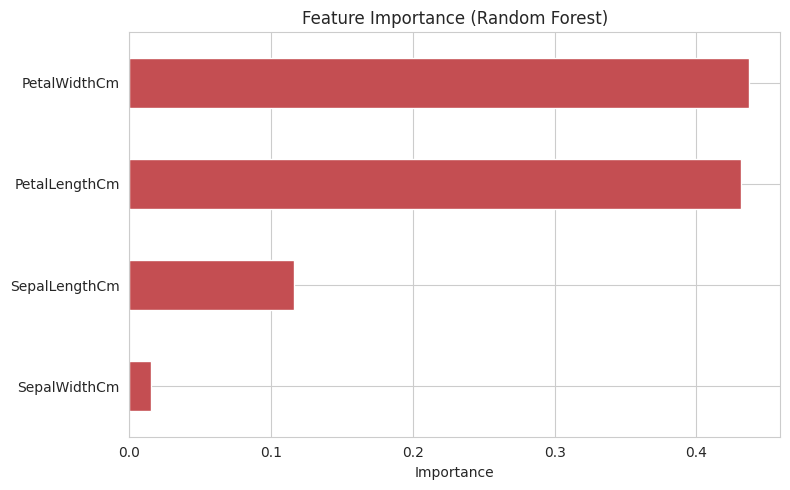

PetalWidthCm     0.437185
PetalLengthCm    0.431466
SepalLengthCm    0.116349
SepalWidthCm     0.015000
dtype: float64


In [20]:
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#C44E52')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

**Insight:** Petal-related features (length and width) carry far more predictive power than sepal features — consistent with the EDA observations.

## 9. Predict on New Samples

In [21]:
new_samples = pd.DataFrame([
    [5.1, 3.5, 1.4, 0.2],   # likely setosa
    [6.7, 3.0, 5.2, 2.3],   # likely virginica
    [5.9, 3.0, 4.2, 1.5],   # likely versicolor
], columns=X.columns)

new_scaled = scaler.transform(new_samples)
preds = best_model.predict(new_scaled)
labels = le.inverse_transform(preds)

result = new_samples.copy()
result['Predicted Species'] = labels
result

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Predicted Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,6.7,3.0,5.2,2.3,Iris-virginica
2,5.9,3.0,4.2,1.5,Iris-versicolor


## 10. Conclusion

- The Iris dataset is a clean, balanced, well-known benchmark for multi-class classification.
- **Petal length** and **petal width** are the most discriminative features.
- Multiple algorithms achieve **≥ 95% accuracy** on the test set; SVM and KNN typically tie for the best result.
- *Iris-setosa* is linearly separable from the other classes; *versicolor* and *virginica* show minor overlap, which accounts for nearly all classification errors.

This task demonstrated the standard supervised-learning workflow: **load → explore → preprocess → train → evaluate → predict** — the foundation of every classification problem in machine learning.